In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading datasets
sales_df = pd.read_csv("data/train.csv", low_memory=False) # sales data 
stores_df = pd.read_csv("data/store.csv") # stores data

In [5]:
# shape of dataframes
print("sales data shape:", sales_df.shape)
print("stores data shape:", stores_df.shape)

sales data shape: (1017209, 9)
stores data shape: (1115, 10)


In [7]:
# sales data sample: 5 ROWS
sales_df.sample(5) # Random 5 rows

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
644055,371,7,2013-12-01,0,0,0,0,0,0
279469,94,6,2014-11-15,5196,515,1,0,0,0
329460,615,2,2014-09-23,6776,1038,1,0,0,0
918958,984,6,2013-03-30,8464,1090,1,0,0,0
773641,617,3,2013-08-07,5225,543,1,0,0,1


In [8]:
# stores data sample: 5 ROWS
stores_df.sample(5) # Random 5 rows

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
361,362,c,c,340.0,NaN,NaN,0,NaN,NaN,NaN
231,232,c,c,13570.0,5.0,2010.0,1,10.0,2013.0,"Mar,Jun,Sept,Dec"
925,926,d,c,5150.0,3.0,2011.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
1106,1107,a,a,1400.0,6.0,2012.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
323,324,a,a,13140.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"


In [10]:
# merging sales dataframe and store dataframe
df = pd.merge(sales_df, stores_df, on='Store', how='left')

In [12]:
# Top 5 rows
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [18]:
def convert_dtypes(df: pd.DataFrame, col: str, dtype=None, inplace: bool=False):
    try:
        if not dtype:
            print("data-type not defined")
        if col not in df.columns:
            print(f"{col} is not present in the given dataframe. The present colunns are: {df.columns}")
        if inplace:
            df[col] = df[col].astype(dtype)
            print("datatype successfully changed...")
        else:
            return df[col].astype(dtype)
    except Exception as e:
        pritn(f"Got exception while changing dtypes: {e}")
            

In [26]:
convert_dtypes(df, 'Store', 'int16', inplace=True)
convert_dtypes(df, 'DayOfWeek', 'int8', inplace=True)
convert_dtypes(df, 'Date', 'datetime64[ns]', inplace=True)


d = {"Store": "int16"}
for key, val in d.items():
    convert_dtypes(df, key, val, inplace=True)

datatype successfully changed...
datatype successfully changed...
datatype successfully changed...


In [33]:
from typing import Literal
def func(stratagy: Literal['mean', "median", "mode", 'const']='mean'):
    return stratagy

In [34]:
fun

'abc'

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int16         
 1   DayOfWeek                  1017209 non-null  int8          
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [28]:
# save file
df.to_csv('data/updated_sales_data.csv', index=False)

In [29]:
# handle missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int16         
 1   DayOfWeek                  1017209 non-null  int8          
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [30]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [31]:
df[df['CompetitionDistance'].isnull()]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,5,2015-07-31,10052,973,1,1,0,1,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,5,2015-07-31,6306,540,1,1,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,5,2015-07-31,6000,466,1,1,0,0,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"
1405,291,4,2015-07-30,9030,883,1,1,0,1,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
1736,622,4,2015-07-30,5412,406,1,1,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015601,622,3,2013-01-02,4080,451,1,0,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
1015858,879,3,2013-01-02,3077,326,1,0,0,1,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"
1016385,291,2,2013-01-01,0,0,0,0,a,1,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
1016716,622,2,2013-01-01,0,0,0,0,a,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN


In [32]:
df['Store'].fillna(0)

0             1
1             2
2             3
3             4
4             5
           ... 
1017204    1111
1017205    1112
1017206    1113
1017207    1114
1017208    1115
Name: Store, Length: 1017209, dtype: int16

In [35]:
def fill_missing(df: pd.DataFrame, col: str,  stratagy: str='mean', const_value=None):
    """\
    stratagy: mean, median, mode, const
    """
    try:
        # df = df.copy()
        if col not in df.columns:
            print(f"{col} is not present in the given dataframe. The present colunns are: {df.columns}")
        if stratagy in ('mean', 'median', 'mode', 'const'):
                if stratagy.lower() == 'mean':
                    
                    df[col] = df[col].fillna(df[col].mean())
                    return df[col]
                    
                elif stratagy.lower() == 'median':
                    df[col] = df[col].fillna(df[col].median())
                    return df[col]
                    
                elif stratagy.lower() == 'mode':
                    df[col] = df[col].fillna(df[col].mode()[0])
                    return df[col]
                    
                elif stratagy.lower() == 'const':
                    if not const_value:
                        print("You must provide a constant value.")
                        
                    else:
                        df[col] = df[col].fillna(const_value)
                        return df[col]
                
                
                print("missing valuessuccessfully filled...")
            
    except Exception as e:
        print(f"Got exception while changing dtypes: {e}")
            

In [62]:
fill_missing(df, 'Promo2SinceWeek',stratagy='median')

0          22.0
1          13.0
2          14.0
3          22.0
4          22.0
           ... 
1017204    31.0
1017205    22.0
1017206    22.0
1017207    22.0
1017208    22.0
Name: Promo2SinceWeek, Length: 1017209, dtype: float64

In [63]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int16         
 1   DayOfWeek                  1017209 non-null  int8          
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1017209 non-null  flo

In [58]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [8]:
# day-2
df = pd.read_csv("data/updated_sales_data.csv", low_memory=False)

In [9]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

<Axes: >

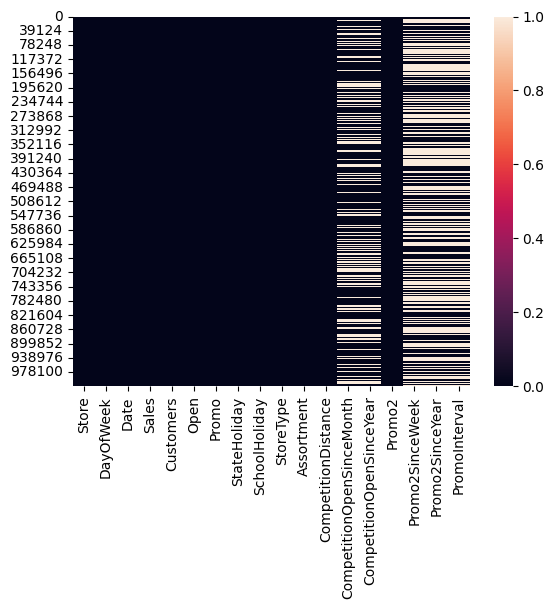

In [26]:
sns.heatmap(df.isnull()) 

In [37]:
# # handling missing valaues 
# df['CompetitionDistance'] = df['CompetitionDistance'].fillna(-1)
# df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(-1)
# fill_missing(df, 'Promo2SinceWeek', stratagy='const', const_value=-1)
# fill_missing(df, 'Promo2SinceYear', stratagy='const', const_value=-1)
fill_missing(df, 'PromoInterval', stratagy='const', const_value='unk')


0                       unk
1           Jan,Apr,Jul,Oct
2           Jan,Apr,Jul,Oct
3                       unk
4                       unk
                 ...       
1017204     Jan,Apr,Jul,Oct
1017205                 unk
1017206                 unk
1017207                 unk
1017208    Mar,Jun,Sept,Dec
Name: PromoInterval, Length: 1017209, dtype: str

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionOpenSinceYea

In [40]:
df = df[df['Open']==1].drop(columns='Open')

In [43]:
df = df[df['Sales']>0].copy()

In [44]:
df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,-1.0,-1.0,unk
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,-1.0,-1.0,unk
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,-1.0,-1.0,unk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,-1.0,-1.0,unk
1016827,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,-1.0,-1.0,unk
1016863,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,-1.0,-1.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct"
1017042,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,-1.0,-1.0,0,-1.0,-1.0,unk


In [45]:
# reseting index
df.reset_index(drop=True, inplace=True)

In [46]:
df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,-1.0,-1.0,unk
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,-1.0,-1.0,unk
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,-1.0,-1.0,unk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844333,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,-1.0,-1.0,unk
844334,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,-1.0,-1.0,unk
844335,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,-1.0,-1.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct"
844336,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,-1.0,-1.0,0,-1.0,-1.0,unk


In [51]:
# top 10 stores by sales
top_10_sales = df.groupby('Store')['Sales'].sum().nlargest(10)

In [56]:
sns.set_theme(palette='magma')

In [60]:
top_10_sales.values

array([19516842, 17057867, 16927322, 16202585, 14896870, 14252406,
       14082141, 14067158, 13489879, 12911782])

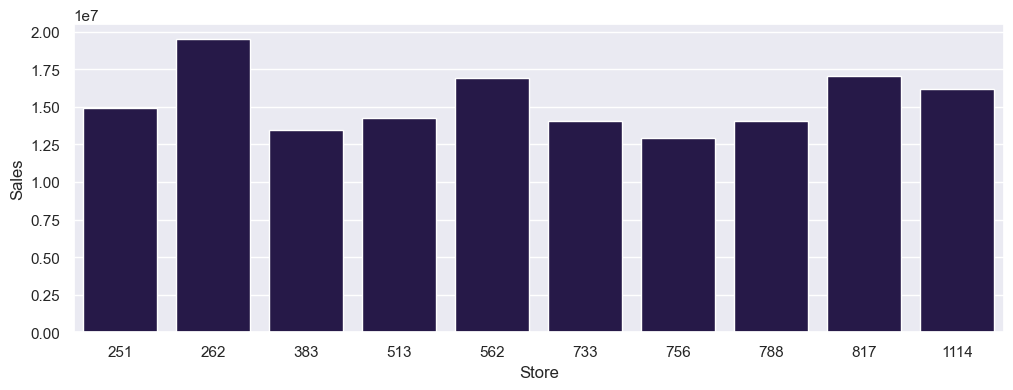

In [63]:
plt.figure(figsize=(12, 4))
sns.barplot(top_10_sales)
plt.show()

<Axes: >

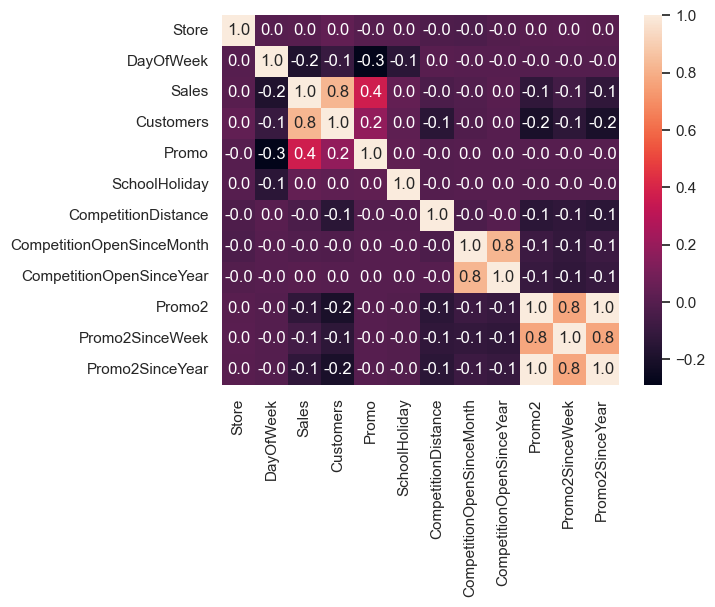

In [66]:
# corr. 
sns.heatmap(df.select_dtypes('number').corr(), fmt='.1f', annot=True)

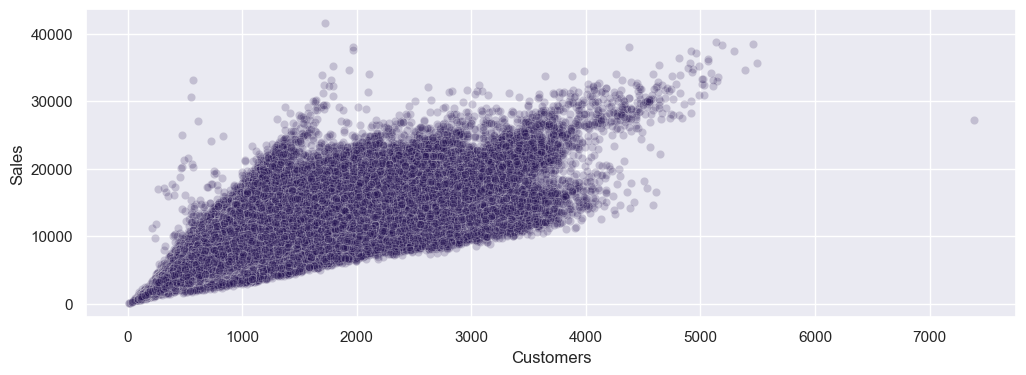

In [71]:
# sales vs customer
plt.figure(figsize=(12, 4))
sns.scatterplot(df, x = 'Customers', y='Sales', alpha=0.2 )
plt.show()

<Axes: xlabel='Customers', ylabel='Sales'>

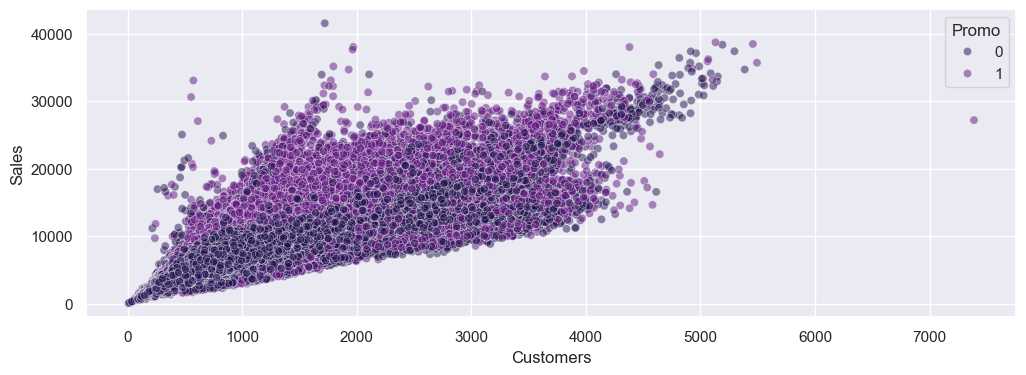

In [73]:
# sales vs customer
plt.figure(figsize=(12, 4))
sns.scatterplot(df, x = 'Customers', y='Sales', alpha=0.5, hue='Promo')

In [75]:
# # sales vs customer
# plt.figure(figsize=(12, 4))
# sns.kdeplot(df, x = 'Customers', y='Sales', alpha=0.5, hue='Promo')
# plt.show()

In [77]:
df[
    'Date'
] = pd.to_datetime(df['Date'])

In [80]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [81]:
df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,-1.0,-1.0,unk,31,7,2015
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",31,7,2015
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",31,7,2015
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,-1.0,-1.0,unk,31,7,2015
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,-1.0,-1.0,unk,31,7,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844333,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,-1.0,-1.0,unk,1,1,2013
844334,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,-1.0,-1.0,unk,1,1,2013
844335,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,-1.0,-1.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",1,1,2013
844336,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,-1.0,-1.0,0,-1.0,-1.0,unk,1,1,2013


In [83]:
df.set_index('Date', inplace=True)

In [84]:
df

,Store,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
Date,,,,,,,,,,,,,,,,,,,
2015-07-31,1,5,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,-1.0,-1.0,unk,31,7,2015
2015-07-31,2,5,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",31,7,2015
2015-07-31,3,5,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",31,7,2015
2015-07-31,4,5,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,-1.0,-1.0,unk,31,7,2015
2015-07-31,5,5,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,-1.0,-1.0,unk,31,7,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-01-01,682,2,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,-1.0,-1.0,unk,1,1,2013
2013-01-01,733,2,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,-1.0,-1.0,unk,1,1,2013
2013-01-01,769,2,5035,1248,0,a,1,b,b,840.0,-1.0,-1.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",1,1,2013


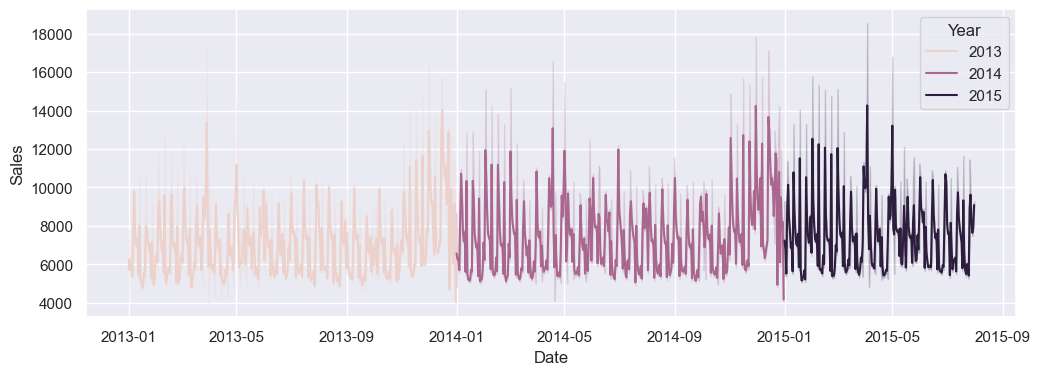

In [92]:
plt.figure(figsize=(12, 4))
sns.lineplot(df, y='Sales', x=df.index, hue='Year')
plt.savefig("img_02.jpg")

<Axes: >

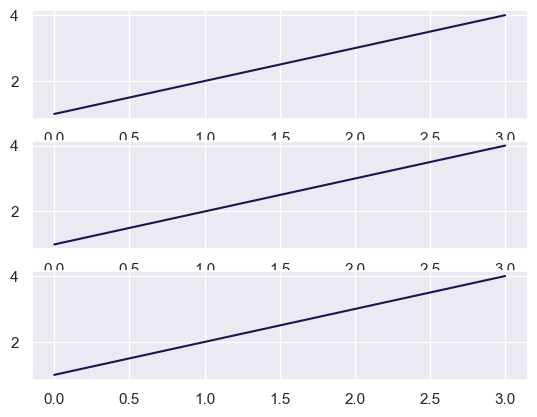

In [90]:
fig, axs = plt.subplots(3)
sns.lineplot(np.array([1,2,3,4]), ax=axs[0])
sns.lineplot(np.array([1,2,3,4]), ax=axs[1])
sns.lineplot(np.array([1,2,3,4]), ax=axs[2])